In [212]:
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm.notebook import tqdm
import scipy.interpolate as interp
from mpl_toolkits.mplot3d import Axes3D

In [213]:
def game(N, p, player):                                         #N number of doors, p number of opened doors, player strategy

    doors = np.zeros((N,2))                                     #all doors are losing and not chosen [0, 0]
    car = random.randint(0, N-1)
    doors[car][0] = 1                                           #1 door is winning and not chosen [1, 0]
    choice = random.randint(0, N-1)
    doors[choice][1] = 1                                        #1 door is losing/winning and chosen [x, 1]

    if car == choice:                                           #move the winning door to second last and the chosen door to last
        doors = np.delete(doors, car, 0)
        doors = np.append(doors, [[1, 1]], 0)                   #winning and chosen
    else:
        doors = np.delete(doors, [car, choice], 0)
        doors = np.append(doors, ([1, 0],[0, 1]), 0)            #winning and not chosen + losing and chosen

    doors = np.delete(doors, [x for x in range(p)], 0)          #because now it's easy to open the other doors

    if player == "keeper":
        if car == choice: return 1
        else: return 0

    if player == "switcher":
        doors = np.delete(doors, np.where(doors[:,1] == 1), 0)  #notice that now the winning door is always last (if it still exists)
        second_choice = random.randint(0, len(doors)-1)
        #doors[second_choice][1] = 1                             #useless but to clarify that now this door is losing/winning and chosen
        if doors[second_choice][0] == 1: return 1
        else: return 0

    if player == "random":
        random_choice = random.randint(0, len(doors)-1)
        #doors[second_choice][1] = 1                             #useless but to clarify that now this door is losing/winning and chosen
        if doors[random_choice][0] == 1: return 1
        else: return 0


In [214]:
N = 10
p = 8
tries = 100000
switcher_wins = 0
keeper_wins = 0
random_wins = 0
for i in tqdm(range(tries)):
    switcher_wins = switcher_wins + game(N, p, "switcher")
    keeper_wins = keeper_wins + game(N, p, "keeper")
    random_wins = random_wins + game(N, p, "random")

  0%|          | 0/100000 [00:00<?, ?it/s]

In [215]:
print(switcher_wins/tries)
print(keeper_wins/tries)
print(random_wins/tries)

0.90183
0.1
0.50033


In [ ]:
N = 10                          #number of doors

x = []      #number of doors
y = []      #number of opened_doors
z = []      #ratio between switcher and keeper
a = []      #keeper winrate
b = []      #switcher winrate

tries = 10000

for i in tqdm(range(3, N+1)):
    if N < 3: continue
    p = i-2
    for j in range(1, p+1):
        x.append(i)
        y.append(j)
        switcher_score = 0
        keeper_score = 0
        for k in range(tries):
            switcher_score = switcher_score + game(i, j, "switcher")
            keeper_score = keeper_score + game(i, j, "keeper")

        ratio = float(keeper_score/switcher_score)
        z.append(ratio)
        a.append(float(keeper_score/tries))
        b.append(float(switcher_score/tries))

  0%|          | 0/6 [00:00<?, ?it/s]

In [217]:
print(x)
print(y)
print(z)
print(a)
print(b)

[3, 4, 4, 5, 5, 5, 6, 6, 6, 6, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8]
[1, 1, 2, 1, 2, 3, 1, 2, 3, 4, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 6]
[0.5022502250225023, 0.6838487972508591, 0.3299814765811061, 0.7638362395754359, 0.49124537607891494, 0.2559739772300763, 0.7551789077212806, 0.5862192074259193, 0.38832609744331886, 0.19736052789442113, 0.8812170860152135, 0.6658619024625785, 0.5127488648271045, 0.329026303645593, 0.16573099415204678, 0.8513037350246653, 0.6903523974581167, 0.5835250805338242, 0.42430555555555555, 0.2956757980529771, 0.13574453473732404]
[0.3348, 0.2587, 0.2494, 0.2015, 0.1992, 0.2046, 0.1604, 0.1642, 0.161, 0.1645, 0.1506, 0.1379, 0.1468, 0.1426, 0.1417, 0.1208, 0.1195, 0.1268, 0.1222, 0.1306, 0.1186]
[0.6666, 0.3783, 0.7558, 0.2638, 0.4055, 0.7993, 0.2124, 0.2801, 0.4146, 0.8335, 0.1709, 0.2071, 0.2863, 0.4334, 0.855, 0.1419, 0.1731, 0.2173, 0.288, 0.4417, 0.8737]


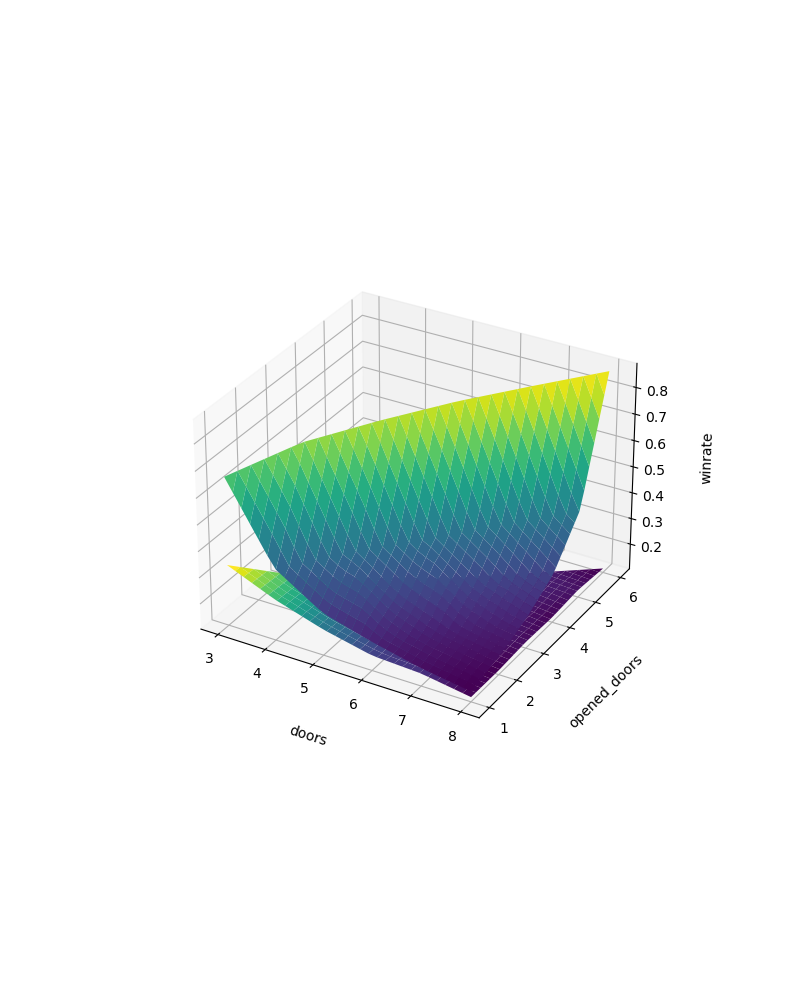

In [ ]:
%matplotlib widget

plotx,ploty = np.meshgrid(np.linspace(np.min(x),np.max(x),30),np.linspace(np.min(y),np.max(y),30))
#plotz = interp.griddata((x,y), z, (plotx,ploty),method='linear')
plota = interp.griddata((x,y), a, (plotx,ploty), method='linear')
plotb = interp.griddata((x,y), b, (plotx,ploty), method='linear')

fig = plt.figure(figsize = (8,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(plotx, ploty, plota, cstride=1, rstride=1, cmap='viridis')
ax.plot_surface(plotx, ploty, plotb, cstride=1, rstride=1, cmap='viridis')
#ax.plot_surface(plotx, ploty, plotz, cstride=1, rstride=1, cmap='viridis')
ax.set_xlabel('doors', labelpad=20)
ax.set_ylabel('opened_doors', labelpad=20)
ax.set_zlabel('winrate', labelpad=20)
ax.set_box_aspect(aspect=None, zoom=0.8)
plt.show()